In [1]:
import pandas as pd
import plotly.express as px

In [6]:


rfm = pd.read_csv("../Customer-Segmentation/rfm_final.csv")

rfm.head()

,Recency,Frequency,Monetary,Churn,AvgOrderValue,PurchaseSpanDays,PurchaseInterval,RepeatRatio,ChurnProbability,RiskSegment,Segment,SegmentName
0,326,12,77556.46,1,6463.038333,400,36.363636,2.4,0.180389,Low Risk,2,VIP Loyal
1,2,8,5633.32,0,704.165000,402,57.428571,1.0,0.179841,Low Risk,2,VIP Loyal
2,75,5,2019.40,0,403.880000,362,90.500000,1.0,0.244381,Low Risk,3,regular
3,19,4,4428.69,0,1107.172500,570,190.000000,1.0,0.112046,Low Risk,3,regular
4,310,1,334.40,1,334.400000,0,0.000000,1.0,0.695524,High Risk,1,Churned


# Segment Size

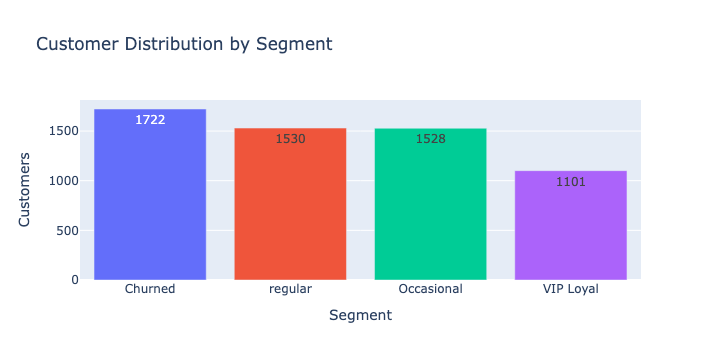

In [8]:
import plotly.express as px

seg_dist = rfm['SegmentName'].value_counts().reset_index()
seg_dist.columns = ['Segment','Customers']

fig_seg = px.bar(
    seg_dist,
    x='Segment',
    y='Customers',
    color='Segment',
    text='Customers',
    title='Customer Distribution by Segment'
)

fig_seg.update_layout(showlegend=False)
fig_seg.show()

# Revenue Contribution

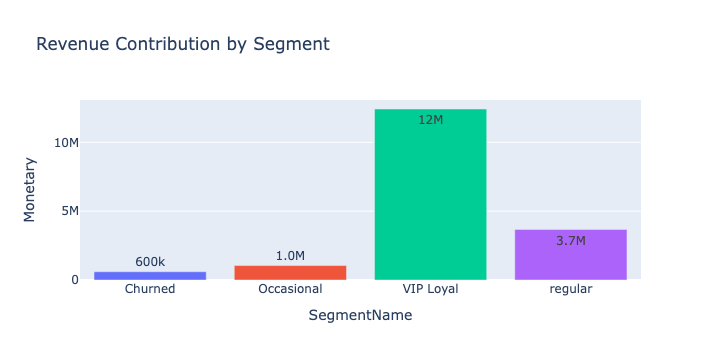

In [9]:
rev_seg = rfm.groupby('SegmentName')['Monetary'].sum().reset_index()

fig_rev = px.bar(
    rev_seg,
    x='SegmentName',
    y='Monetary',
    color='SegmentName',
    text_auto='.2s',
    title='Revenue Contribution by Segment'
)

fig_rev.update_layout(showlegend=False)
fig_rev.show()

# Churn Risk by Segment 

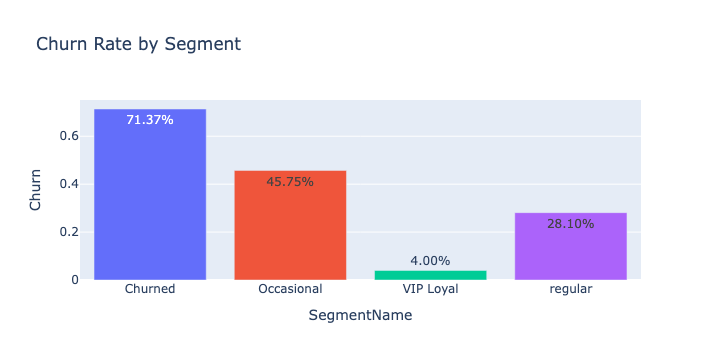

In [10]:
churn_seg = rfm.groupby('SegmentName')['Churn'].mean().reset_index()

fig_churn = px.bar(
    churn_seg,
    x='SegmentName',
    y='Churn',
    color='SegmentName',
    text_auto='.2%',
    title='Churn Rate by Segment'
)

fig_churn.update_layout(showlegend=False)
fig_churn.show()

# Customer Behavior Map (RFM)

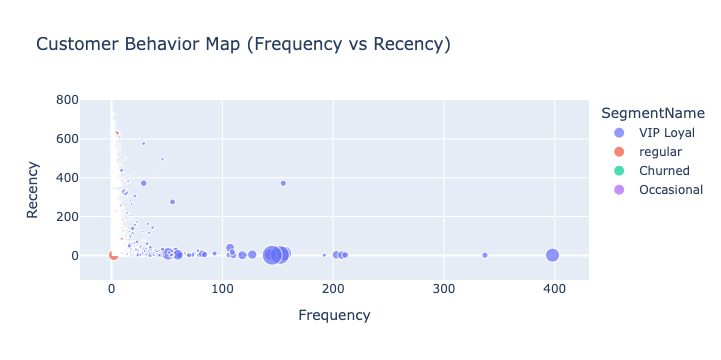

In [11]:
fig_rfm = px.scatter(
    rfm,
    x='Frequency',
    y='Recency',
    color='SegmentName',
    size='Monetary',
    title='Customer Behavior Map (Frequency vs Recency)'
)

fig_rfm.show()

# Purchase Interval Distribution

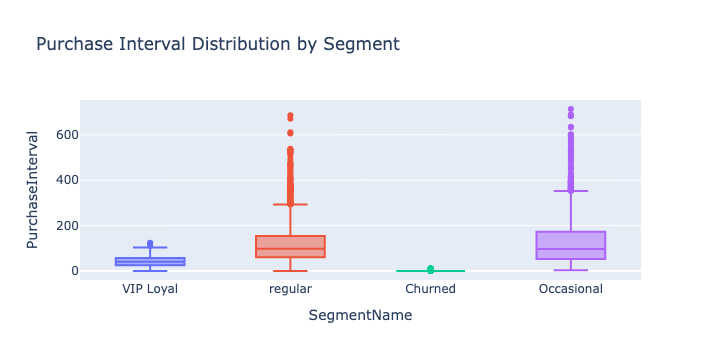

In [12]:
fig_interval = px.box(
    rfm,
    x='SegmentName',
    y='PurchaseInterval',
    color='SegmentName',
    title='Purchase Interval Distribution by Segment'
)

fig_interval.update_layout(showlegend=False)
fig_interval.show()